1. Выполните сохранение монохромного изображения в виде текстового или бинарного файла.

2. Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.

3. Выполните квантование высокочастотных компонент (прим., количество квантов = 4).

4. Сохраните получившийся массив значений в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа.
   Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).

Сравните объем памяти, занимаемый исходным изображением (попиксельное хранение), и изображение, полученным после преобразования Хафа и сжатием длин серий.

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

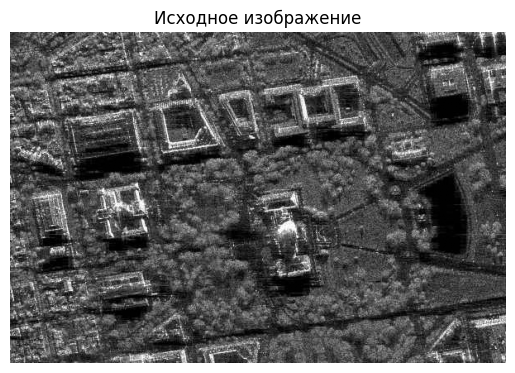

In [27]:
# Загрука монохромного изображения
image_path = 'sar_1_gray.jpg'
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Изображение {image_path} не найдено!")

image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

In [28]:
# Создание бинарного файла
bin_image_file_path = 'image_gray.bin'

with open(bin_image_file_path, 'wb') as f:
    image_gray.tofile(f)

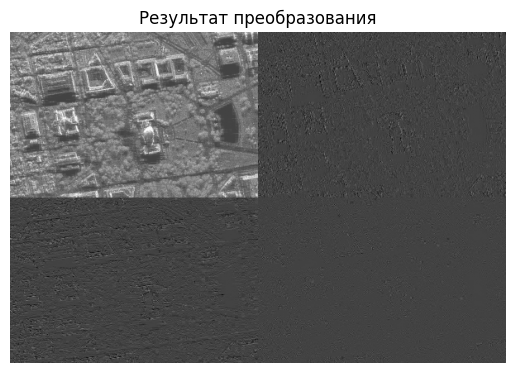

In [ ]:
#вейвлет-преобразования Хаара
h, w = image_gray.shape
h = h - h % 2
w = w - w % 2
image_gray = image_gray[:h, :w].astype(np.float32)
result = np.zeros_like(image_gray)

temp = np.zeros_like(image_gray)
for i in range(h):
    for j in range(0, w, 2):
        a, b = image_gray[i, j], image_gray[i, j+1]
        temp[i, j//2] = (a + b) / np.sqrt(2)
        temp[i, j//2 + w//2] = (a - b) / np.sqrt(2)

for j in range(w):
    for i in range(0, h, 2):
        a, b = temp[i, j], temp[i+1, j]
        result[i//2, j] = (a + b) / np.sqrt(2)
        result[i//2 + h//2, j] = (a - b) / np.sqrt(2)

plt.imshow(result, cmap='gray')
plt.title('Результат преобразования')
plt.axis('off')
plt.show()

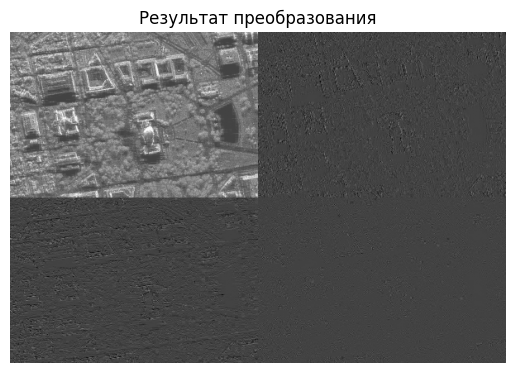

In [30]:
quant_levels = 4

ll_component = result[:h//2, :w//2]
lh_component = result[:h//2, w//2:]
hl_component = result[h//2:, :w//2]
hh_component = result[h//2:, w//2:]

#квантование
def quantize_component(data, levels):
    min_val = np.min(data)
    max_val = np.max(data)
    step = (max_val - min_val) / levels
    return np.floor((data - min_val) / step).astype(int)

lh_quantized = quantize_component(lh_component, quant_levels)
hl_quantized = quantize_component(hl_component, quant_levels)
hh_quantized = quantize_component(hh_component, quant_levels)

result_quantized = result.copy()
result_quantized[:h//2, w//2:] = lh_quantized
result_quantized[h//2:, :w//2] = hl_quantized
result_quantized[h//2:, w//2:] = hh_quantized

plt.imshow(result, cmap='gray')
plt.title('Результат преобразования')
plt.axis('off')
plt.show()

In [31]:
def run_length_encode(data):
    flat = data.flatten()
    counts = {}
    for val in flat:
        counts[val] = counts.get(val, 0) + 1
    return [(val, count) for val, count in counts.items()]
    

lh_encoded = run_length_encode(lh_quantized)
hl_encoded = run_length_encode(hl_quantized)
hh_encoded = run_length_encode(hh_quantized)

In [ ]:
binary_output_path = 'image_components.bin'

with open(binary_output_path, 'wb') as f:
    ll_uint8 = np.clip(ll_component, 0, 255).astype(np.uint8)
    h2, w2 = ll_uint8.shape
    np.array([h2, w2], dtype=np.uint16).tofile(f)
    ll_uint8.tofile(f)

    for encoded in [lh_encoded, hl_encoded, hh_encoded]:
        n = len(encoded)
        np.array([n], dtype=np.uint16).tofile(f)
        if n > 0:
            values = np.array([v for v, c in encoded], dtype=np.uint8)
            counts = np.array([c for v, c in encoded], dtype=np.uint16)
            values.tofile(f)
            counts.tofile(f)

In [36]:
original_size = os.path.getsize(bin_image_file_path)
compressed_size = os.path.getsize(binary_output_path)

print(f"Размер исходного бинарного файла: {original_size} байт ({original_size/1024:.2f} КБ)")
print(f"Размер сжатого файла: {compressed_size} байт ({compressed_size/1024:.2f} КБ)")
print(f"Коэффициент сжатия: {original_size/compressed_size:.2f}")

Размер исходного бинарного файла: 240000 байт (234.38 КБ)
Размер сжатого файла: 60055 байт (58.65 КБ)
Коэффициент сжатия: 4.00
